In [1]:
import os
os.chdir("../")
import pandas as pd
from typing import List
import pickle
import json
import re
from alti_analysis.utils import create_directory_structure, load_model_tokenizer

import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
def read_file(fname):
    output = []
    with open(fname) as f:
        for line in f:
            output.append(line.strip())
    return output

def read_jsonl(fname):
    output = []
    with open(fname, 'r', encoding='utf-8') as file:
        for line in file:
            output.append(json.loads(line))
    return output

def read_json(fname):
    with open(fname, 'r', encoding='utf-8') as file:
            output = json.load(file)
    return output

def read_pickle(picklepath):
    with open(picklepath, 'rb') as file:
        data = pickle.load(file)
    return data
    
def get_contributions_data(contr_folder):
    contr_path = os.path.join(contr_folder,"aggregated_contributions.pkl")
    ids_path = os.path.join(contr_folder,"ids.json")
    segments_path = os.path.join(contr_folder,"segments.json")
    contributions = read_pickle(contr_path)
    ids = read_json(ids_path)
    segments = read_json(segments_path)
    contributions = [contr[-1] for contr in contributions] #keep last layer contributions
    return contributions,ids,segments




In [3]:
CONTR_folder = "/mnt/scratch-artemis/manos/data/wmt24_chat_mt/alti_contributions_official_total_aggregated"
LANGS = ["en-de","en-fr","en-ko","en-nl","en-pt"]
NUM_turns=10
LEVEL = "turn-level"  # or context-level

In [4]:
context_dict = {"TowerChat":f"full_context_empty_sys_{NUM_turns}_turns",
                "TowerInstr":f"full_context_{NUM_turns}_turns"}
model_dict = {"TowerChat":"TowerInstruct-7B-w-chat-empty-sys_fp16_tok370",
                "TowerInstr":"TowerInstruct-7B-v0.2_fp16_tok370"}

data_dict = {}
for lp in LANGS:
    data_dict[lp]= {}
    tower_chat_data=[]
    tower_instr_data=[]
    #load TowerCHat data
    model="TowerChat"
    contrdolder = os.path.join(CONTR_folder, context_dict[model],model_dict[model],lp,LEVEL)
    contrs,ids,segments = get_contributions_data(contrdolder)
    for contr,id,seg in zip(contrs,ids,segments):
        tower_chat_data.append({f"{model}_id":id,f"{model}_contrs":contr,f"{model}_segments":seg})
    tower_chat_pd = pd.DataFrame(tower_chat_data)
    #load TowerInstr data
    model="TowerInstr"
    contrdolder = os.path.join(CONTR_folder, context_dict[model],model_dict[model],lp,LEVEL)
    contrs,ids,segments = get_contributions_data(contrdolder)
    for contr,id,seg in zip(contrs,ids,segments):
        tower_instr_data.append({f"{model}_id":id,f"{model}_contrs":contr,f"{model}_segments":seg})
    tower_instr_pd = pd.DataFrame(tower_instr_data)
    #on the new dataframe we keep the intersection of sample samples!
    merged_df = pd.merge(tower_chat_pd, tower_instr_pd, left_on='TowerChat_id', right_on='TowerInstr_id', how='inner')
    data_dict[lp] = merged_df.copy()
    

In [5]:
#filter out instances that have the same output for both models.
_, tokenizer_instr = load_model_tokenizer("Unbabel/TowerInstruct-7B-v0.2", torch_dtype=torch.float16,only_tokenizer=True)
_, tokenizer_chat = load_model_tokenizer("/mnt/data-poseidon/sweta/chat-translation-generation/TowerInstruct-v0.2-w-chat-mt-data",
                                         torch_dtype=torch.float16,only_tokenizer=True)
def equal_gen(x):
    return tokenizer_instr.decode(x["TowerInstr_segments"]["gen"])==tokenizer_chat.decode(x["TowerChat_segments"]["gen"])

for lp in LANGS:
    df = data_dict[lp].copy()
    num_before = len(df)
    filt_df = df[~df.apply( lambda x: equal_gen(x) , axis=1)]
    num_after = len(filt_df)
    print(f"{lp}  before: {num_before}  after:  {num_after}  percentage filtered:{1-num_after/num_before} ")
    data_dict[lp] = filt_df.copy()


en-de  before: 857  after:  607  percentage filtered:0.29171528588098017 
en-fr  before: 908  after:  663  percentage filtered:0.26982378854625555 
en-ko  before: 846  after:  759  percentage filtered:0.1028368794326241 
en-nl  before: 846  after:  713  percentage filtered:0.1572104018912529 
en-pt  before: 758  after:  550  percentage filtered:0.27440633245382584 


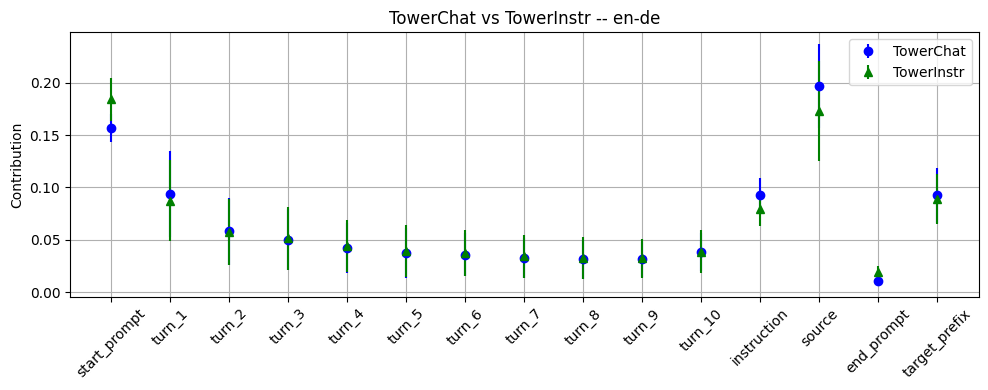

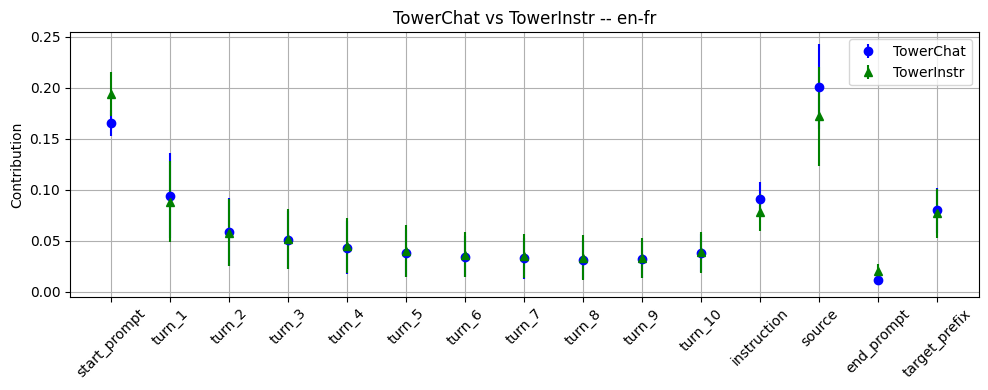

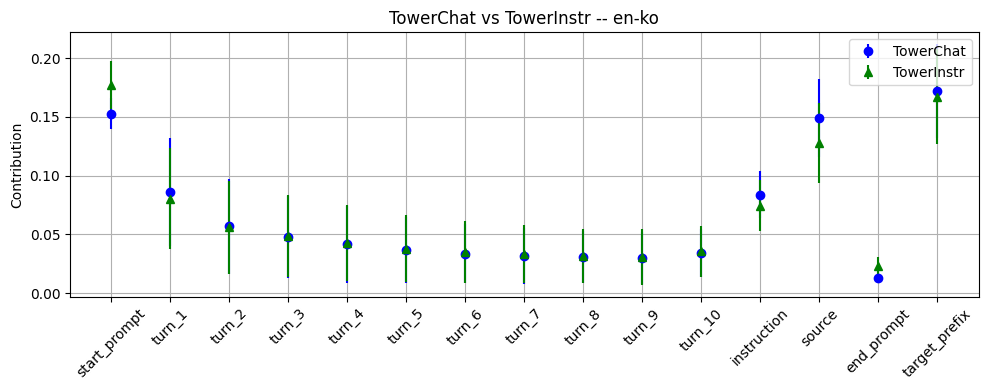

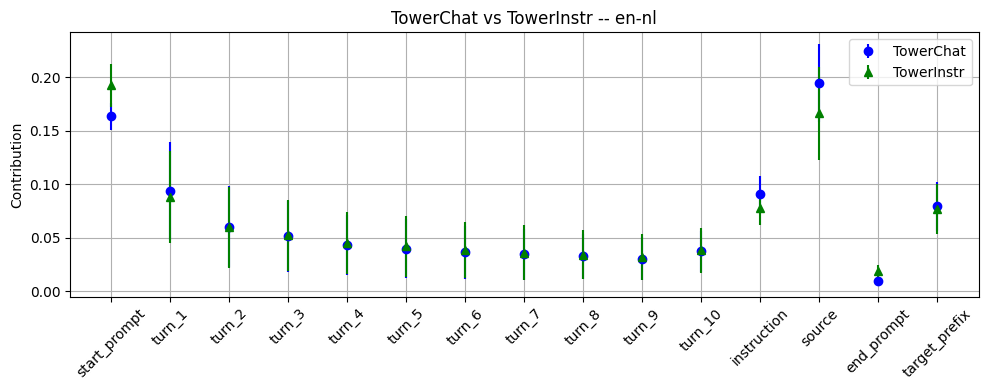

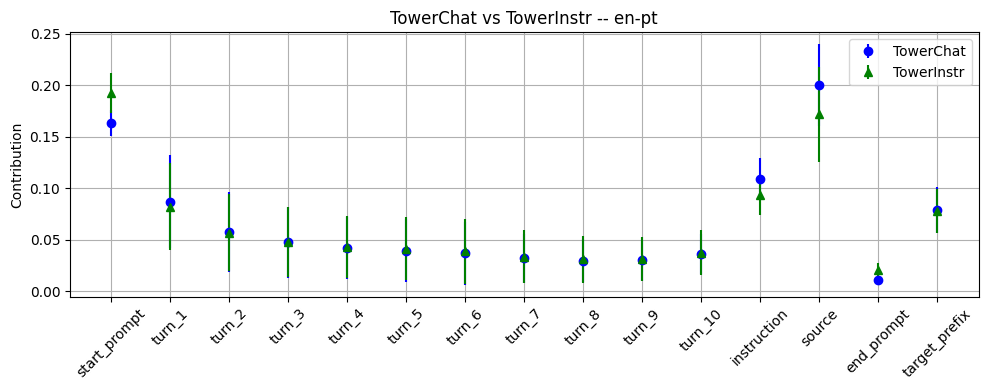

In [6]:

for lang in LANGS:
    contrs_tower_chat = torch.stack(data_dict[lang]["TowerChat_contrs"].tolist(),dim=0).numpy().squeeze(1)
    contrs_tower_instr = torch.stack(data_dict[lang]["TowerInstr_contrs"].tolist(),dim=0).numpy().squeeze(1)
    x_labels = list(data_dict[lang]["TowerChat_segments"].iloc[0].keys())[:-1]


    # Compute means and standard deviations for TowerChat and TowerInstr
    chat_mean = np.mean(contrs_tower_chat, axis=0)
    chat_std = np.std(contrs_tower_chat, axis=0)
    
    instr_mean = np.mean(contrs_tower_instr, axis=0)
    instr_std = np.std(contrs_tower_instr, axis=0)
    # Create the plot
    plt.figure(figsize=(10, 4))
    
    # Plot means for TowerChat with error bars
    plt.errorbar(x_labels, chat_mean, yerr=chat_std, label='TowerChat', 
                 marker='o', color='blue',linestyle='' )
    
    # Plot means for TowerInstr with error bars
    plt.errorbar(x_labels, instr_mean, yerr=instr_std, label='TowerInstr', 
                 marker='^', color='green', linestyle='' )
    
    # Adding titles and labels
    plt.title(f"TowerChat vs TowerInstr -- {lang}")
    # plt.xlabel(r"Segments")
    plt.ylabel(r"Contribution")
    plt.legend()

    plt.xticks(rotation=45)
    
    # Show the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()


- instead of averaging the contributions maybe take maximum or minimum(?)

- instead of treating the generated sequence as a single segment, to use bins(?)

#### Comet/PCXMI signals -- analysis
Use comet or pcxmi signals check in which cases context is useful. Examine these cases specifically.


- use pcxmi signal to find cases where context is useful 
- use comet signal to find best TowerChathat vs towerInstr repsonses and check these
- check also Pecore paper

In [27]:
def get_pcxmi_sentence_mean_log_probs(lp, context_type,model_name, split="test"):
    source_lang = lp.split("-")[0].replace('pt','pt-br')
    target_lang = lp.split("-")[1].replace('pt','pt-br')
    #read  logprobs!
    probs_hyp = read_file(f"pcxmi/{context_type}/mt/wmt24_chat_{split}.{source_lang}-{target_lang}/{model_name}/mean_log_probs_hyp.txt")
    probs_ref = read_file(f"pcxmi/{context_type}/mt/wmt24_chat_{split}.{source_lang}-{target_lang}/{model_name}/mean_log_probs_ref.txt")
    assert  len(probs_hyp)==len(probs_ref), "Log probs lengths for hyp and ref not equal"
    return {"hyp":probs_hyp,"ref":probs_ref}


def get_eval_comet_scores(lp, context_type,model_name, split="test"):
    source_lang = lp.split("-")[0].replace('pt','pt-br')
    target_lang = lp.split("-")[1].replace('pt','pt-br')
    #read comet_kiwi_scores for each turn
    eval_data = read_json(f"evaluations/{context_type}/mt/wmt24_chat_{split}.{source_lang}-{target_lang}/vllm/{model_name}/evaluation.json")
    return eval_data["comet_segments"]


def filter_samples(ids_keep,all_samples):
    tmp_dict = {}
    for i,score in enumerate(all_samples):
        tmp_dict[i] = score
    return [tmp_dict[i] for i in ids_keep]

In [48]:
context_dict = {"TowerChat":f"full_context_empty_sys_{NUM_turns}_turns",
                "TowerInstr":f"full_context_{NUM_turns}_turns"}
model_name_dict = {"TowerChat":"TowerInstruct-7B-w-chat-empty-sys",
                "TowerInstr":"TowerInstruct-7B-v0.2"}

pcxmi_model_name_dict = {"TowerChat":"TowerInstruct-v0.2-w-chat-mt-data",
                "TowerInstr":"TowerInstruct-7B-v0.2"}

comet_scores = {}
for lang in LANGS:
    # add columns of comet-scores  for TowerChat 
    comet_scores_all = get_eval_comet_scores(lang,context_dict['TowerChat'],model_name_dict['TowerChat'])
    comet_scores = filter_samples(data_dict[lang].TowerChat_id.values,comet_scores_all)
    data_dict[lang]['comet_TowerChat'] = comet_scores
    # pcxmi_scores_all = get_pcxmi_sentence_mean_log_probs(lang,context_dict["TowerChat"],pcxmi_model_name_dict['TowerChat'])["hyp"]


    # add columns of comet-scores  for  TowerInstr
    comet_scores_all = get_eval_comet_scores(lang,context_dict['TowerInstr'],model_name_dict['TowerInstr'])
    comet_scores = filter_samples(data_dict[lang].TowerChat_id.values,comet_scores_all)  #ids for TowerChat and TowerInstr are the same since we consider the intersection of samples
    data_dict[lang]['comet_TowerInstr'] = comet_scores
    # pcxmi_scores_all = get_pcxmi_sentence_mean_log_probs(lang,context_dict["TowerInstr"],pcxmi_model_name_dict['TowerInstr'])["hyp"]



##### Comet based Deviation Analysis:
we select the isntances that have a high deviation in terms of comet scores between the two models. For these specific samples we analyse the contributions.


In [61]:
high_deviation_comet={}
for lang in LANGS:
    high_deviation_comet[lang] = data_dict[lang][((data_dict[lang]['comet_TowerChat'] - data_dict[lang]['comet_TowerInstr'])*100 >=10)]
    print(f"for {lang} -- # samples: {((data_dict[lang]['comet_TowerChat'] - data_dict[lang]['comet_TowerInstr'])*100 >=10).sum()} out of {len(data_dict[lang])}")
    

for en-de -- # samples: 37 out of 607
for en-fr -- # samples: 44 out of 663
for en-ko -- # samples: 61 out of 759
for en-nl -- # samples: 61 out of 713
for en-pt -- # samples: 49 out of 550


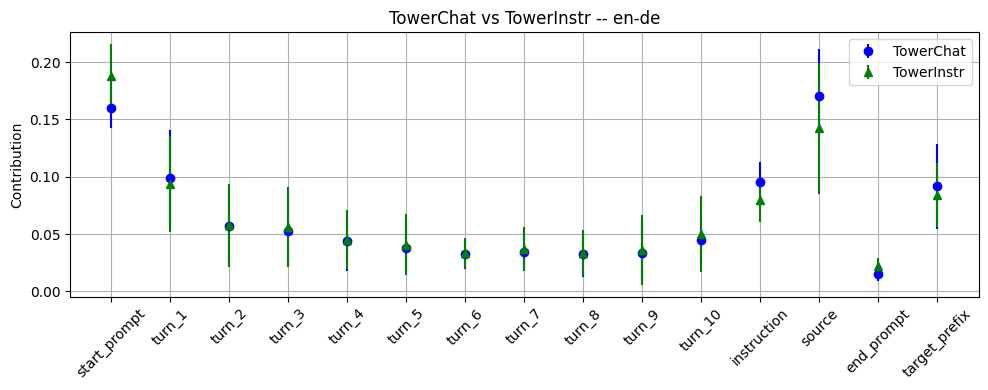

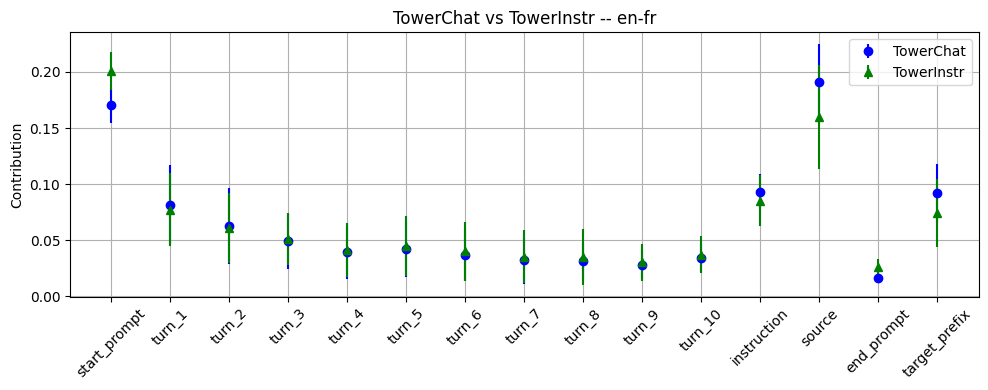

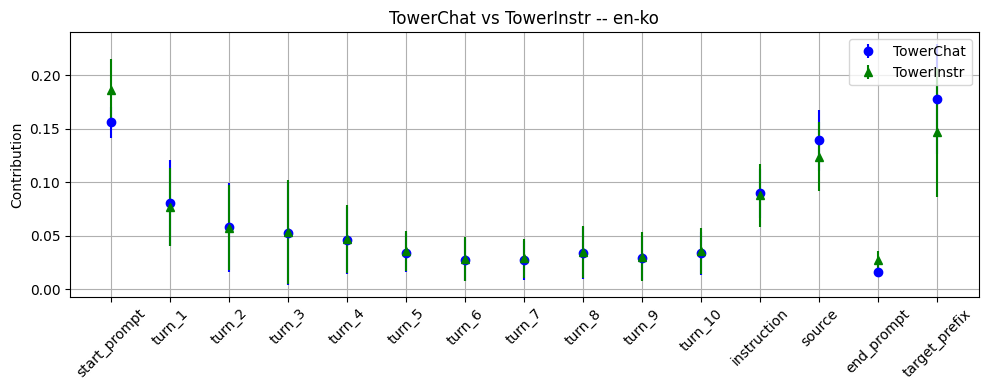

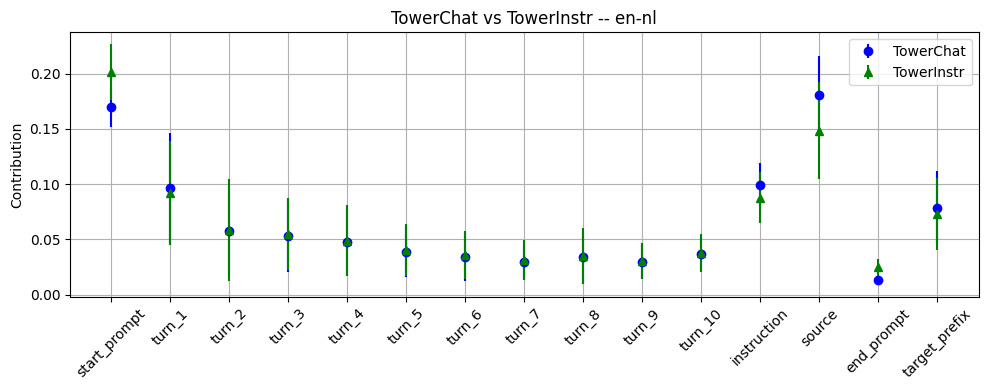

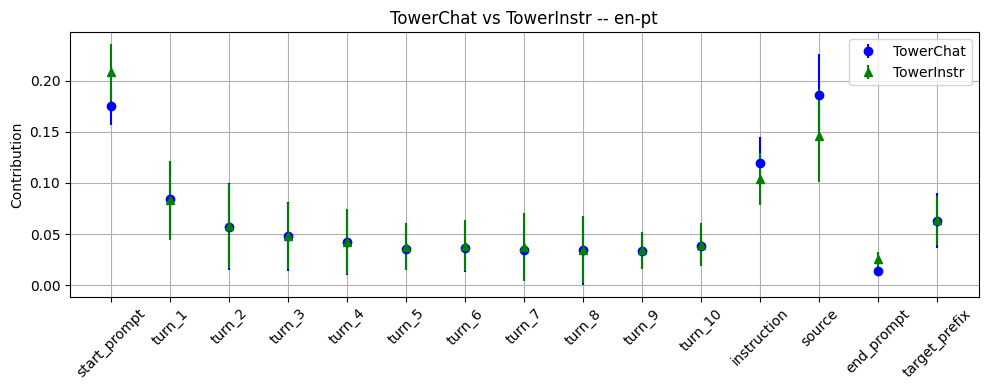

In [76]:
for lang in LANGS:
    contrs_tower_chat = torch.stack(high_deviation_comet[lang]["TowerChat_contrs"].tolist(),dim=0).numpy().squeeze(1)
    contrs_tower_instr = torch.stack(high_deviation_comet[lang]["TowerInstr_contrs"].tolist(),dim=0).numpy().squeeze(1)
    x_labels = list(high_deviation_comet[lang]["TowerChat_segments"].iloc[0].keys())[:-1]


    # Compute means and standard deviations for TowerChat and TowerInstr
    chat_mean = np.mean(contrs_tower_chat, axis=0)
    chat_std = np.std(contrs_tower_chat, axis=0)
    
    instr_mean = np.mean(contrs_tower_instr, axis=0)
    instr_std = np.std(contrs_tower_instr, axis=0)
    # Create the plot
    plt.figure(figsize=(10, 4))
    
    # Plot means for TowerChat with error bars
    plt.errorbar(x_labels, chat_mean, yerr=chat_std, label='TowerChat', 
                 marker='o', color='blue',linestyle='' )
    
    # Plot means for TowerInstr with error bars
    plt.errorbar(x_labels, instr_mean, yerr=instr_std, label='TowerInstr', 
                 marker='^', color='green', linestyle='' )
    
    # Adding titles and labels
    plt.title(f"TowerChat vs TowerInstr -- {lang}")
    # plt.xlabel(r"Segments")
    plt.ylabel(r"Contribution")
    plt.legend()

    plt.xticks(rotation=45)
    
    # Show the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()


It seems that we dont have huge differences on the contributions! Let's qualitatively check this:


In [75]:
for index,instance in high_deviation_comet["en-pt"].iterrows():
    print("Instance ID:",instance["TowerChat_id"])
    input_seg_keys = ['start_prompt', 'turn_1', 'turn_2', 'turn_3', 'turn_4', 'turn_5', 'turn_6', 'turn_7', 'turn_8', 'turn_9', 'turn_10', 'instruction', 'source']
    for key in input_seg_keys:
        print(key, tokenizer_chat.decode(instance["TowerChat_segments"][key]))
    print("")
    print("TowerChat GEN :",tokenizer_chat.decode(instance["TowerChat_segments"]["gen"]) , "  comet: ",instance["comet_TowerChat"])
    print("TowerInstr GEN :",tokenizer_instr.decode(instance["TowerInstr_segments"]["gen"]),  "  comet: ",instance["comet_TowerInstr"])

    print("Contributions TowerChat: ", instance["TowerChat_contrs"])
    print("Contributions TowerInstr: ", instance["TowerInstr_contrs"])
    print("")
    print("")
    print("")

    

Instance ID: 15
start_prompt <s><|im_start|> system
<|im_end|> 
<|im_start|> user

turn_1 Context: Yes, all your payment information

turn_2 estou a trabalhar e não tenho o cartão aqui, terei de contactar mais tarde.

turn_3 tem de ser em chat?

turn_4 nao gosto de dar numeros de cartão assim

turn_5 Oh, no, you don't need to provide you r payment information, On this case, you should need to fill the information in your account, not to the agent.

turn_6 And yes, we have customer service 24/7

turn_7 Do you have any other question?

turn_8 Are you still with me?

turn_9 I will close this chat now since no response has been received.

turn_10 I will gladly continue assisting you via email, or you can contact us again at a more convenient time for you.


instruction Translate the English source text to Brazilian Portuguese, given the context.

source English: Have a nice day
Brazilian Portuguese: 

TowerChat GEN : Tenha um bom dia!   comet:  0.9921268224716187
TowerInstr GEN : Boa tarde